In [1]:
import utils as ut
import pandas as pd

# Validation

#### Model Type Selection + Unsmoothed LL Tuning + Benchmarks

In [29]:
static_benchmarks = pd.read_parquet(f'{ut.results_dir}/benchmarks/summary/')
ll_tuning_run = pd.read_parquet(f'{ut.results_dir}/model_selection/summary/')

# Selecting relevant columns
ll_tuning_run['model_name'] = ll_tuning_run['hurdle_model'].map({True: 'LL_hurdle', False: 'LL_NB'})
ll_tuning_run = ll_tuning_run[['w_inf', 'model_name', 'test_valid', 'non_degen_ll', 'run_timestamp']]
static_benchmarks['w_inf'] = 0

results = pd.concat([ll_tuning_run, static_benchmarks])
results.sort_values(by='non_degen_ll', ascending=False).head()

,w_inf,model_name,test_valid,non_degen_ll,run_timestamp
20,0.240,LL_hurdle,valid,-1.401773,20260724_175737_636570
21,0.245,LL_hurdle,valid,-1.401773,20260724_175823_795589
4,0.250,LL_hurdle,valid,-1.401800,20260724_151038_031518
19,0.235,LL_hurdle,valid,-1.401802,20260724_175651_350184
18,0.230,LL_hurdle,valid,-1.401859,20260724_175604_941838


In [28]:
# If your column is named "log_degen_ll"
results = results.reset_index(drop=True)
results.loc[results.groupby('model_name')['non_degen_ll'].idxmax()].sort_values(by='non_degen_ll', ascending=False)

,w_inf,model_name,test_valid,non_degen_ll,run_timestamp
20,0.24,LL_hurdle,valid,-1.401773,20260724_175737_636570
8,0.15,LL_NB,valid,-1.431368,20260724_152051_312411
31,0.00,user_hour_hurdle,valid,-1.481319,20260724_171140_506156
30,0.00,user_hurdle,valid,-1.486078,20260724_171140_506156


#### Cluster Smoothing validaiton performance

In [6]:
cluster_smoothing = pd.read_parquet(f'{ut.results_dir}/cluster_smoothing/nll_only/summary/')

In [13]:
cluster_smoothing.sort_values(by='non_degen_smoothed_ll', ascending=False).head(10)

,smoothed_model_name,experiment_name,sampling_seed,w_inf,cluster_param,smooth_a_mu,smooth_a_sigma2,smooth_a_p,smooth_t_mu,smooth_t_sigma2,...,hurdle_model,test_valid,non_degen_ll,non_degen_smoothed_ll,clustering_matrix_name,clustering_transformation,distance_metric,clustering_seed,cluster_inertia,run_timestamp
307,k_clusters,cluster_smoothing,6654,0.33,30,0.7,0.55,0.4,0.0,0.0,...,True,valid,-1.412296,-1.397817,u_p,none,standardised_l2,6554,80015.273438,20260730_203536_272239
386,k_clusters,cluster_smoothing,6654,0.32,24,0.5,0.55,0.4,0.0,0.0,...,True,valid,-1.411380,-1.397861,all,none,standardised_l2,6554,121252.390625,20260730_220110_197218
385,k_clusters,cluster_smoothing,6654,0.31,30,0.6,0.60,0.3,0.0,0.0,...,True,valid,-1.410585,-1.397892,u_p,none,standardised_l2,6554,80015.273438,20260730_220005_935587
357,k_clusters,cluster_smoothing,6654,0.32,24,0.6,0.50,0.5,0.0,0.0,...,True,valid,-1.411380,-1.397893,all,none,standardised_l2,6554,121252.390625,20260730_212956_165050
330,k_clusters,cluster_smoothing,6654,0.32,32,0.5,0.50,0.5,0.0,0.0,...,True,valid,-1.411380,-1.397933,u_p,none,standardised_l2,6554,77954.406250,20260730_210037_124869
339,k_clusters,cluster_smoothing,6654,0.33,26,0.6,0.60,0.6,0.0,0.0,...,True,valid,-1.412296,-1.397982,all,none,standardised_l2,6554,112586.375000,20260730_211023_742747
310,k_clusters,cluster_smoothing,6654,0.32,28,0.6,0.55,0.5,0.0,0.0,...,True,valid,-1.411380,-1.397985,all,none,standardised_l2,6554,107635.953125,20260730_203853_886779
305,k_clusters,cluster_smoothing,6654,0.31,32,0.5,0.55,0.5,0.0,0.0,...,True,valid,-1.410585,-1.398030,u_p,none,standardised_l2,6554,77954.406250,20260730_203319_259385
321,k_clusters,cluster_smoothing,6654,0.31,26,0.7,0.60,0.5,0.0,0.0,...,True,valid,-1.410585,-1.398081,u_p,none,standardised_l2,6554,87277.500000,20260730_205053_023171
398,k_clusters,cluster_smoothing,6654,0.31,28,0.7,0.60,0.5,0.0,0.0,...,True,valid,-1.410585,-1.398089,u_p,none,standardised_l2,6554,82832.218750,20260730_221404_042971


#### Global Smoothing Validation performance

In [2]:
global_smoothing = pd.read_parquet(f'{ut.results_dir}/global_smoothing/nll_only/summary/')

In [3]:
global_smoothing.sort_values(by='non_degen_smoothed_ll', ascending=False).head()

,smoothed_model_name,experiment_name,sampling_seed,w_inf,cluster_param,smooth_a_mu,smooth_a_sigma2,smooth_a_p,smooth_t_mu,smooth_t_sigma2,...,hurdle_model,test_valid,non_degen_ll,non_degen_smoothed_ll,clustering_matrix_name,clustering_transformation,distance_metric,clustering_seed,cluster_inertia,run_timestamp
235,k_clusters,global_smoothing,6654,0.33,1,0.55,0.55,0.25,0.0,0.0,...,True,valid,-1.412296,-1.400743,u,none,l2,6554,0.0,20260730_235309_885521
298,k_clusters,global_smoothing,6654,0.32,1,0.45,0.55,0.30,0.0,0.0,...,True,valid,-1.411380,-1.400866,u,none,l2,6554,0.0,20260731_005217_555315
241,k_clusters,global_smoothing,6654,0.33,1,0.45,0.55,0.25,0.0,0.0,...,True,valid,-1.412296,-1.400873,u,none,l2,6554,0.0,20260730_235853_539463
280,k_clusters,global_smoothing,6654,0.34,1,0.50,0.50,0.35,0.0,0.0,...,True,valid,-1.413337,-1.400883,u,none,l2,6554,0.0,20260731_003536_097128
244,k_clusters,global_smoothing,6654,0.33,1,0.55,0.45,0.25,0.0,0.0,...,True,valid,-1.412296,-1.400909,u,none,l2,6554,0.0,20260731_000144_953936


# Test

In [2]:
import l_result_preperation as l
import matplotlib.pyplot as plt
import utils as ut
import os 
import m_plots as m

outputs_dir = f'{ut.project_root}/outputs'
os.makedirs(outputs_dir, exist_ok=True)

In [2]:
# Loading in test results and concat together
runtime_configs = ut.load_json5('runtime_configs')
ll_full_results, ll_user_results, benchmark_results = l.load_test_results(results_dir=ut.results_dir, n_test_seeds=runtime_configs['n_test_seeds'])

##### Processing Data

In [3]:
overall_performance = l.get_all_model_performance_table(ll_full_results=ll_full_results, benchmark_results=benchmark_results)
l.store_results(overall_performance, ut.results_dir, 'overall_performance')

In [4]:
model_comparisons = l.prepare_model_comparisons(ll_user_results=ll_user_results, overall_performance=overall_performance)
l.store_results(model_comparisons, ut.results_dir, 'model_comparisons')

In [5]:
activity_decile = l.get_activity_decile_improvement(ll_full_results=ll_full_results)
l.store_results(activity_decile, ut.results_dir, 'activity_decile')

In [6]:
distance_decile = l.get_distance_decile_improvement(ll_user_results=ll_user_results)
l.store_results(distance_decile, ut.results_dir, 'distance_decile')

In [7]:
calibration = l.get_calibration_summary(ll_full_results=ll_full_results)
l.store_results(calibration, ut.results_dir, 'calibration')

In [8]:
user_type_summary = l.get_user_type_summary(ll_full_results=ll_full_results)
l.store_results(user_type_summary, ut.results_dir, 'user_type_summary')

##### Activity decile plot

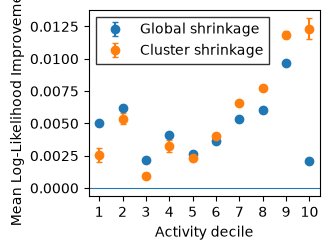

In [9]:
activity_decile = l.load_results( ut.results_dir, 'activity_decile')
fig, ax = m.declile_log_likelihood_plot(decile_results=activity_decile, x_label='Activity decile', relative=False)
# fig.savefig(f'{outputs_dir}/activity_decile.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()

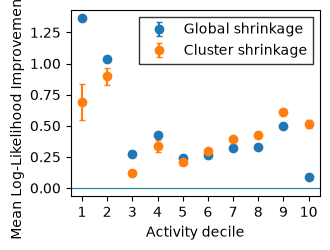

In [10]:
activity_decile = l.load_results(ut.results_dir, 'activity_decile')
fig, ax = m.declile_log_likelihood_plot(decile_results=activity_decile, x_label='Activity decile', relative=True)
# fig.savefig(f'{outputs_dir}/activity_decile_relative.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()

##### Distance decile plot

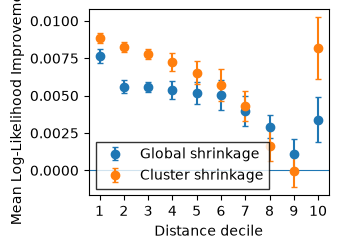

In [11]:
distance_decile = l.load_results( ut.results_dir, 'distance_decile')
fig, ax = m.declile_log_likelihood_plot(decile_results=distance_decile, x_label='Distance decile', relative=False)
# fig.savefig(f'{outputs_dir}/distance_decile.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()

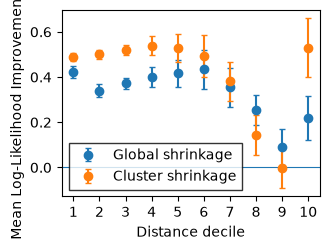

In [12]:
distance_decile = l.load_results(ut.results_dir, 'distance_decile')
fig, ax = m.declile_log_likelihood_plot(decile_results=distance_decile, x_label='Distance decile', relative=True)
# fig.savefig(f'{outputs_dir}/distance_decile_relative.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()

##### Calibration plot

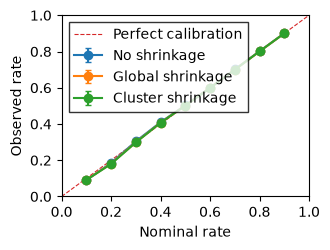

In [13]:
calibration = l.load_results( ut.results_dir, 'calibration')
fig, ax = m.plot_calibration(calibration_df=calibration, extreme=False)
# fig.savefig(f'{outputs_dir}/ordinary_calibration.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()

##### Extreme Calibration Table + plot

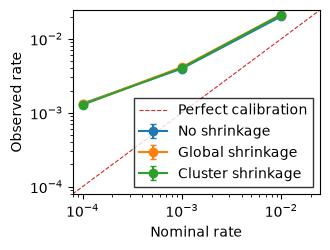

In [3]:
calibration = l.load_results( ut.results_dir, 'calibration')
fig, ax = m.plot_calibration(calibration_df=calibration, extreme=True)
# fig.savefig(f'{outputs_dir}/extreme_calibration.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()

In [12]:
calibration = l.load_results(ut.results_dir, 'calibration',)
extreme_calibration_output = l.get_extreme_calibration_output(calibration)
extreme_calibration_output
# extreme_calibration_output.to_csv(f'{outputs_dir}/extreme_calibration.csv', index=False)

,threshold,no_smoothing_mean,global_smoothing_mean,cluster_smoothing_mean,no_smoothing_sd,global_smoothing_sd,cluster_smoothing_sd
0,0.0001,0.001331,0.001301,0.001285,5.757338e-07,5.574655e-07,0.000003
1,0.0010,0.003967,0.004148,0.004045,1.268469e-06,1.329141e-06,0.000009
2,0.0100,0.020175,0.021348,0.021198,3.696288e-06,3.300186e-06,0.000019


##### User Type Breakdown Table

In [13]:
user_type_summary = l.load_results( ut.results_dir, 'user_type_summary')
user_type_output = l.get_user_type_output(user_type_summary)
user_type_output

# user_type_output.to_csv(f'{outputs_dir}/user_type_performance.csv', index=False)

,user_type,no_smoothing,global_smoothing,cluster_smoothing,cluster_smoothing_seed_sd
0,Human,-1.017284,-1.016099,-1.015898,0.000209
1,Machine,-1.619664,-1.612576,-1.610595,0.000102


##### Overall Comparison Table

In [14]:
overall_performance = l.load_results( ut.results_dir, 'overall_performance')
overall_performance_output = l.get_overall_performance_output(overall_performance)
overall_performance_output
# overall_performance_output.to_csv(f'{outputs_dir}/overall_performance.csv', index=False)

,model,mean_log_likelihood,seed_sd
0,No shrinkage,-1.376381,NaN
1,Global shrinkage,-1.371676,NaN
2,Cluster shrinkage,-1.370415,0.000122
3,User level benchmark,-1.460846,NaN
4,Hourly user benchmark,-1.452264,NaN


##### 3 Way comparison table

In [15]:
model_comparisons = l.load_results( ut.results_dir, 'model_comparisons')
model_comparison_output = l.get_model_comparison_output(model_comparisons)
model_comparison_output
# model_comparison_output.to_csv(f'{outputs_dir}/model_comparisons.csv', index=False)

,model_comparison,mean_log_likelihood_difference,median_user_ll_difference,users_improved_pct
0,Global shrinkage - No shrinkage,0.004705,0.001909,61.365985
1,Cluster shrinkage - No shrinkage,0.005966,0.002996,65.486408
2,Cluster shrinkage - Global shrinkage,0.001262,0.000824,69.723658
